In [423]:
import nltk
import numpy as np
import pandas as pd
import os
import re
import Basic_functions as bf  #Homemade script.
import time

import matplotlib.pyplot as plt


from nltk import word_tokenize
from nltk.tokenize import WordPunctTokenizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer


###################################################

#https://gist.github.com/berteltorp/0cf8a0c7afea7f25ed754f24cfc2467b Stopords liste
stopwords_danish = np.genfromtxt(r"C:\Users\Geniet\AppliedML\AppML_Project\stopord.txt", dtype = "str", encoding="utf-8")
default_stopwords = set(stopwords.words('english'))

extended_stopwords = default_stopwords.union(stopwords_danish)

In [403]:
#test = open("Speeches\A._Bartholdy_Møllers_prædiken_1._søndag_efter_paske.txt", "r", encoding="utf-8").read().strip()

def import_txt_files_to_array(folder_path):
    txt_files_content = []
    txt_year          = []
    Files_read = 0

    for filename in os.listdir(folder_path):
        if filename.endswith('.txt'):
            Files_read = Files_read + 1
            file_path = os.path.join(folder_path, filename)
            try:
                with open(file_path, 'r', encoding='utf-8') as file:
                    content = file.read()
                    # Split at the first occurrence of "\n\n\n" and take the part after it
                    parts = content.split('\n\n\n', 1)
                    if len(parts) > 1:
                        text_after_marker = parts[1]
                    else:
                        text_after_marker = content  # Fallback if "\n\n\n" not found

                    # Replace escaped newlines (\\n) with spaces, then remove all newlines
                    text_after_marker = text_after_marker.replace('\\n', ' ').replace('\n', ' ')

                    # Convert to lowercase, keep letters (including æøå), spaces, and remove ellipses
                    cleaned_text = re.sub(r'[^a-zA-ZæøåÆØÅ\s]', '', text_after_marker.lower())
                    cleaned_text = cleaned_text.replace("'", "")
                    cleaned_text = cleaned_text.replace('...', '')  # Remove ellipses

                    # Remove extra spaces (e.g., multiple spaces)
                    cleaned_text = ' '.join(cleaned_text.split())

                    txt_files_content.append(cleaned_text)


                    ############################################

                    year_part = content.split('\n', 2)
                    year_after_marker = (year_part[1].split('-',1))[0]
                    cleaned_year = year_after_marker.replace('Date: ', "")
                    try:
                        txt_year.append(float(cleaned_year))
                    except:
                        txt_year.append(0)
                    
            except Exception as e:
                print(f"Error reading {filename}: {e}")
    print('Files read:', Files_read)

    return txt_files_content, txt_year

# Example usage:
folder_path = r'C:\Users\Geniet\AppliedML\AppML_Project\ML2026_Project\Speeches'  # Replace with your folder path
df, df_year = import_txt_files_to_array(folder_path)

print('done')
#skip = test.find('\n\n\n')
#Raw_test = test[skip:].lower()
#nltk.download('all')


Files read: 4753
done


In [405]:
len(df_year)

4753

In [407]:
df2 = pd.DataFrame(df, columns = ['text'])


In [409]:
def preprocess(text):
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word.isalpha() and word not in extended_stopwords]
    return " ".join(tokens)

####################################

start = time.time()

df_clean = df2['text'].apply(preprocess)
df_clean = pd.DataFrame(df_clean, columns = ['text'])
dfpd_year = pd.DataFrame(df_year, columns = ['year'])
dfpd = pd.concat([df_clean, dfpd_year], axis = 1)

stop = time.time()

print(f'Time preprocessing: {stop-start:3f} seconds')

Time preprocessing: 21.171595 seconds


In [410]:
dfpd

,text,year
0,landsmænd danske studenter fædreland skylder u...,1942.0
1,udpræget centralt skønne evangelium kristus sa...,1945.0
2,syndsforladelsens naade fortællingen jesu møde...,1944.0
3,ord indeholder herlig forjættelse jesus gav di...,1945.0
4,gode livsråd grønlands fremtid bærer ansvaret ...,2025.0
...,...,...
4748,oh thank much dont know say heart jumping uhør...,2022.0
4749,excellencies distinguished delegates partners ...,2024.0
4750,towards green reading european charter local s...,2022.0
4751,retten uddannelse børn særligt piger vigtigste...,2022.0


In [411]:
vectorizer = TfidfVectorizer(use_idf=False, lowercase=True, token_pattern=r'(?u)\b[A-Za-zæøå]+\b')
X = vectorizer.fit_transform(dfpd['text'])
y = dfpd['year']
print("TF-IDF matrix shape:", X.shape) # 174594 words is too much >:(

TF-IDF matrix shape: (4753, 174615)


In [412]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [419]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
print(xgboost.__version__)

model = xgb.XGBRegressor(objective='reg:squarederror',
                         n_estimators=100, random_state=42)
start = time.time()

model.fit(X_train, y_train)

stop = time.time()
print(f'Training time: {stop - start:3f} seconds')

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'RMSE: {rmse:.3f}')
print(f'R²: {r2:.3f}')

model.save_model('model.bin')

3.0.0
Training time: 53.826607 seconds
RMSE: 72.486
R²: 0.260


C:\Users\Geniet\AppliedML\AppliedML2026\appmlenv\Lib\site-packages\xgboost\sklearn.py:1028: UserWarning: [21:36:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\c_api\c_api.cc:1427: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats.
  self.get_booster().save_model(fname)


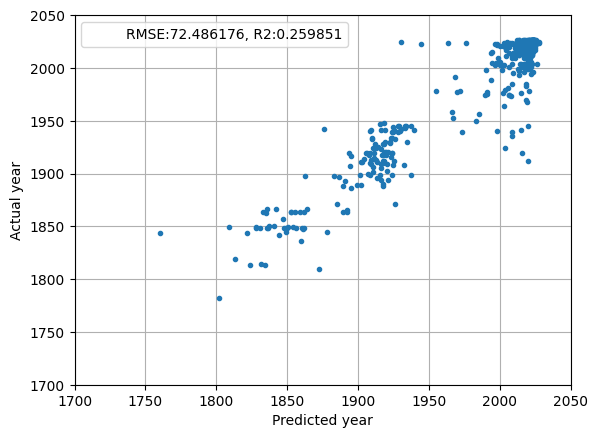

In [445]:
plt.plot(y_pred,y_test, '.')
plt.xlabel('Predicted year')
plt.ylabel('Actual year')
plt.xlim(1700,2050)
plt.ylim(1700,2050)

plt.plot([],[], ' ', label = f'RMSE:{rmse:3f}, R2:{r2:3f}')
plt.grid()
plt.legend()


<h1> Text Classification</h1>